In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from itertools import combinations
from collections import Counter
from sklearn.model_selection import train_test_split

import sys
import os

# add project root to Python path
sys.path.append(os.path.abspath(".."))
from src.models.poisson import get_lambda
from src.models.poisson import train_model
from src.models.poisson import evaluate_poisson



### World Cup Tournament Flow
With 12 groups of 4 teams:
- Top 2 teams from each group = 24 teams
- Best 8 third-place teams = 8 teams   
- Total = 32 teams → Knockout stage

In [2]:
# FIFA World Cup 2026 Group Stages
world_cup_2026_groups = {
    "A": ["Mexico", "South Africa", "South Korea", "Czechia"],
    "B": ["Canada", "Bosnia and Herzegovina", "Qatar", "Switzerland"],
    "C": ["Brazil", "Morocco", "Haiti", "Scotland"],
    "D": ["USA", "Paraguay", "Australia", "Türkiye"],
    "E": ["Germany", "Curacao", "Ivory Coast", "Ecuador"],
    "F": ["Netherlands", "Japan", "Sweden", "Tunisia"],
    "G": ["Belgium", "Egypt", "Iran", "New Zealand"],
    "H": ["Spain", "Cape Verde", "Saudi Arabia", "Uruguay"],
    "I": ["France", "Senegal", "Iraq", "Norway"],
    "J": ["Argentina", "Algeria", "Austria", "Jordan"],
    "K": ["Portugal", "Congo DR", "Uzbekistan", "Colombia"],
    "L": ["England", "Croatia", "Ghana", "Panama"]
}


In [3]:
ROUND_OF_32 = [
    (("A", 1), ("B", 2)),
    (("C", 1), ("D", 2)),
    (("E", 1), ("F", 2)),
    (("G", 1), ("H", 2)),
    (("I", 1), ("J", 2)),
    (("K", 1), ("L", 2)),

    (("B", 1), ("A", 2)),
    (("D", 1), ("C", 2)),
    (("F", 1), ("E", 2)),
    (("H", 1), ("G", 2)),
    (("J", 1), ("I", 2)),
    (("L", 1), ("K", 2)),
]

def simulate_match(team1, team2, elo_dict, beta_home, beta_away):
    """
    Simulate a single match using Poisson goal model.
    """

    lam_a, lam_b = get_lambda(
        team1, team2,
        elo_dict,
        beta_home,
        beta_away
    )

    goals_a = np.random.poisson(lam_a)
    goals_b = np.random.poisson(lam_b)

    if goals_a > goals_b:
        return team1
    elif goals_b > goals_a:
        return team2
    else:
        return np.random.choice([team1, team2])


def simulate_group(group_teams, elo_dict, beta_home, beta_away):

    table = {
        team: {"points": 0, "gd": 0, "goals": 0}
        for team in group_teams
    }

    for team_a, team_b in combinations(group_teams, 2):

        lam_a, lam_b = get_lambda(
            team_a, team_b,
            elo_dict,
            beta_home,
            beta_away
        )

        goals_a = np.random.poisson(lam_a)
        goals_b = np.random.poisson(lam_b)

        table[team_a]["goals"] += goals_a
        table[team_b]["goals"] += goals_b

        table[team_a]["gd"] += goals_a - goals_b
        table[team_b]["gd"] += goals_b - goals_a

        if goals_a > goals_b:
            table[team_a]["points"] += 3
        elif goals_b > goals_a:
            table[team_b]["points"] += 3
        else:
            table[team_a]["points"] += 1
            table[team_b]["points"] += 1

    return sorted(
        table.items(),
        key=lambda x: (x[1]["points"], x[1]["gd"], x[1]["goals"]),
        reverse=True
    )


# SIMULATE ALL GROUPS
def simulate_group_stage(groups, elo_dict, beta_home, beta_away):

    group_results = {}
    third_place = []

    for group_name, teams in groups.items():

        standings = simulate_group(
            teams, elo_dict, beta_home, beta_away
        )

        group_results[group_name] = standings

        # store 3rd place
        third_place.append((group_name, standings[2]))

    return group_results, third_place

def get_best_third_places(third_place):

    ranked = sorted(
        third_place,
        key=lambda x: (
            x[1][1]["points"],
            x[1][1]["gd"],
            x[1][1]["goals"]
        ),
        reverse=True
    )

    return ranked[:8]

def get_knockout_teams(group_results, best_thirds):

    teams = []

    # top 2 from each group
    for group, standings in group_results.items():
        teams.append(standings[0][0])
        teams.append(standings[1][0])

    # add best 3rd
    for group_name, (team, stats) in best_thirds:
        teams.append(team)

    assert len(teams) == 32

    return teams

def seed_knockout(teams, elo_dict):
    return sorted(teams, key=lambda t: elo_dict.get(t, 1500), reverse=True)


def create_bracket(teams):
    return [(teams[i], teams[-i-1]) for i in range(len(teams)//2)]

def simulate_knockout_round(teams, elo_dict, beta_home, beta_away):

    matches = [(teams[i], teams[i+1]) for i in range(0, len(teams), 2)]

    winners = []

    for t1, t2 in matches:
        winners.append(simulate_match(t1, t2, elo_dict, beta_home, beta_away))

    return winners

def simulate_tournament(groups, elo_dict, beta_home, beta_away):

    progression = {team: {"R32":1,"R16":0,"QF":0,"SF":0,"Final":0,"Winner":0}
                   for group in groups.values() for team in group}

    # --- GROUP STAGE ---
    group_results, third_place = simulate_group_stage(
        groups, elo_dict, beta_home, beta_away
    )

    # --- BEST 3rd ---
    best_thirds = get_best_third_places(third_place)

    # --- 32 TEAMS ---
    knockout_teams = get_knockout_teams(group_results, best_thirds)

    for t in knockout_teams:
        progression[t]["R32"] = 1

    # --- STRUCTURED BRACKET ---
    seeded = seed_knockout(knockout_teams, elo_dict)

    # --- KNOCKOUTS ---
    r32 = simulate_knockout_round(seeded, elo_dict, beta_home, beta_away)
    for team in r32:
        progression[team]["R16"] += 1

    r16 = simulate_knockout_round(r32, elo_dict, beta_home, beta_away)
    for team in r16:
        progression[team]["QF"] += 1

    qf = simulate_knockout_round(r16, elo_dict, beta_home, beta_away)
    for team in qf:
        progression[team]["SF"] += 1
    sf = simulate_knockout_round(qf, elo_dict, beta_home, beta_away)
    for team in sf:
        progression[team]["Final"] += 1
    final = simulate_knockout_round(sf, elo_dict, beta_home, beta_away)
    for team in final:
        progression[team]["Winner"] += 1

    # Return winner
    return final[0], progression

def run_simulations(n, groups, elo_dict, beta_home, beta_away):
    winners = []
    progression_totals = {}

    for team in [t for g in groups.values() for t in g]:
        progression_totals[team] = {
            "R32":0,"R16":0,"QF":0,"SF":0,"Final":0,"Winner":0
        }

    for _ in range(n):

        winner, progression = simulate_tournament(
            groups,
            elo_dict,
            beta_home,
            beta_away
        )

        winners.append(winner)

        for team in progression:
            for stage in progression[team]:
                progression_totals[team][stage] += progression[team][stage]

    return Counter(winners), progression_totals

In [4]:
def get_match_result(row):
    if row["home_goals"] > row["away_goals"]:
        return 0  # Home win
    elif row["home_goals"] == row["away_goals"]:
        return 1  # Draw
    else:
        return 2  # Away win

In [ ]:
df = pd.read_csv("../data/processed/matches_with_features.csv")
final_elo = pd.read_csv("../data/processed/final_elo.csv")

# Split data into training & test sets
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)


y_test = test_df.apply(get_match_result, axis=1).values

beta_home, beta_away = train_model(train_df)
elo_dict = dict(zip(final_elo['team'], final_elo["elo"]))

In [6]:
# Evaluate Poisson Model
poisson_logloss, poisson_brier = evaluate_poisson(
    test_df,
    y_test,
    elo_dict,
    beta_home,
    beta_away
)

print("Poisson Log Loss:", poisson_logloss)
print("Poisson Brier:", poisson_brier)

Poisson Log Loss: 0.9642254977122197
Poisson Brier: 0.5686455949344797


c:\Users\Admin\anaconda3\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


In [7]:
beta_home, beta_away

(array([0.47184942, 0.00241987]), array([0.11466832, 0.00251324]))

In [8]:
# No. of simulations to run
n = 5000

results, progression_totals = run_simulations(
    n,
    world_cup_2026_groups,
    elo_dict,
    beta_home,
    beta_away
)

In [9]:
# Normalize Progression
df_prog = pd.DataFrame(progression_totals).T / n

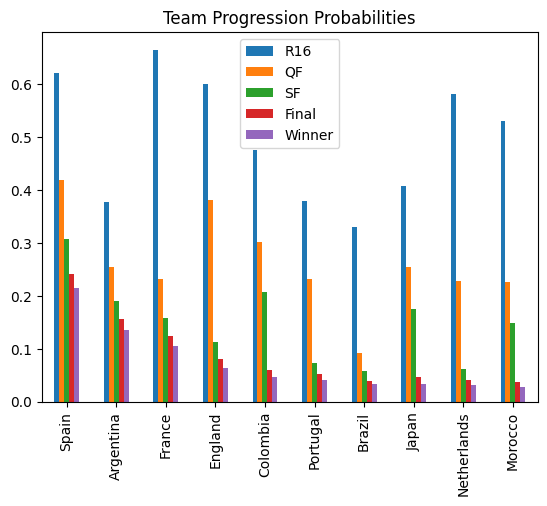

In [10]:
top = df_prog.sort_values("Winner", ascending=False).head(10)

top[["R16","QF","SF","Final","Winner"]].plot(kind="bar")
plt.title("Team Progression Probabilities")
plt.show()

In [11]:
df_results = pd.DataFrame.from_dict(results, orient="index", columns=["wins"])
df_results["probability"] = df_results["wins"] / df_results["wins"].sum()

df_results = df_results.sort_values("probability", ascending=False)

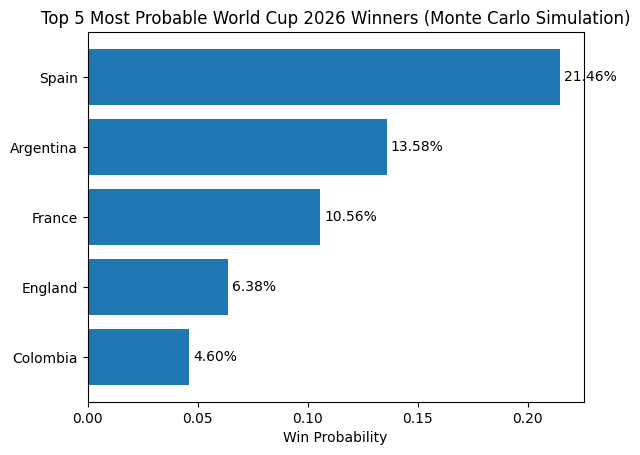

In [12]:

top_n = 5
top_teams = df_results.head(top_n)

plt.figure()

plt.barh(top_teams.index[::-1], top_teams["probability"][::-1])

for i, v in enumerate(top_teams["probability"][::-1]):
    plt.text(v + 0.002, i, f"{v:.2%}", va='center')

plt.xlabel("Win Probability")
plt.title("Top 5 Most Probable World Cup 2026 Winners (Monte Carlo Simulation)")

plt.show()

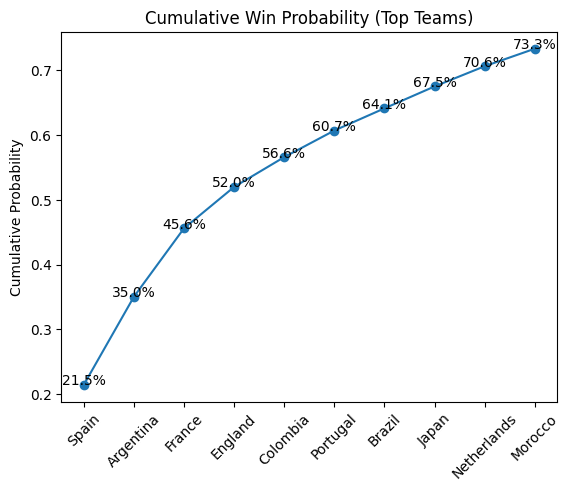

In [13]:
df_results["cumulative_prob"] = df_results["probability"].cumsum()

top_n = 10
top = df_results.head(top_n)

plt.figure()
plt.plot(top.index, top["cumulative_prob"], marker="o")

for i, v in enumerate(top["cumulative_prob"]):
    plt.text(i, v, f"{v:.1%}", ha='center')

plt.title("Cumulative Win Probability (Top Teams)")
plt.ylabel("Cumulative Probability")
plt.xticks(rotation=45)

plt.show()

### Evaluate Progression Totals



In [14]:
progression_totals

{'Mexico': {'R32': 5000,
  'R16': 2342,
  'QF': 976,
  'SF': 310,
  'Final': 63,
  'Winner': 44},
 'South Africa': {'R32': 5000,
  'R16': 1184,
  'QF': 527,
  'SF': 216,
  'Final': 39,
  'Winner': 2},
 'South Korea': {'R32': 5000,
  'R16': 2063,
  'QF': 956,
  'SF': 634,
  'Final': 450,
  'Winner': 107},
 'Czechia': {'R32': 5000,
  'R16': 1202,
  'QF': 612,
  'SF': 261,
  'Final': 72,
  'Winner': 11},
 'Canada': {'R32': 5000,
  'R16': 2287,
  'QF': 1207,
  'SF': 489,
  'Final': 347,
  'Winner': 69},
 'Bosnia and Herzegovina': {'R32': 5000,
  'R16': 1117,
  'QF': 429,
  'SF': 132,
  'Final': 24,
  'Winner': 3},
 'Qatar': {'R32': 5000,
  'R16': 956,
  'QF': 389,
  'SF': 144,
  'Final': 30,
  'Winner': 2},
 'Switzerland': {'R32': 5000,
  'R16': 2173,
  'QF': 1179,
  'SF': 756,
  'Final': 544,
  'Winner': 121},
 'Brazil': {'R32': 5000,
  'R16': 1656,
  'QF': 462,
  'SF': 286,
  'Final': 199,
  'Winner': 171},
 'Morocco': {'R32': 5000,
  'R16': 2656,
  'QF': 1130,
  'SF': 745,
  'Final': 18

In [15]:
df_prog = pd.DataFrame(progression_totals).T

# COnvert progression counts to probabilities
df_prog = df_prog / n

df_prog = df_prog.sort_values("Winner", ascending=False)
df_prog = df_prog * 100

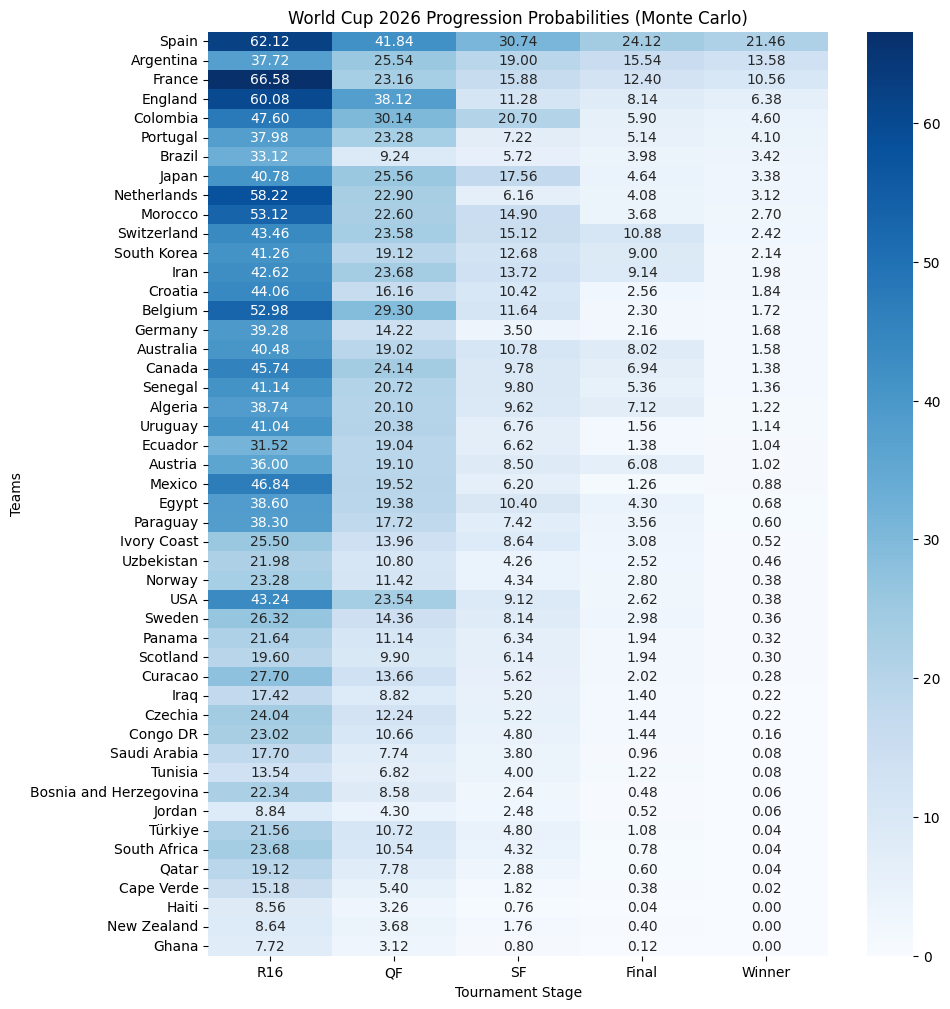

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 12))

sns.heatmap(
    df_prog[["R16", "QF", "SF", "Final", "Winner"]],
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("World Cup 2026 Progression Probabilities (Monte Carlo)")
plt.ylabel("Teams")
plt.xlabel("Tournament Stage")

plt.show()

In [17]:
# TOP TEAMS
top_teams = df_prog.head(16)
top_teams

,R32,R16,QF,SF,Final,Winner
Spain,100.0,62.12,41.84,30.74,24.12,21.46
Argentina,100.0,37.72,25.54,19.00,15.54,13.58
France,100.0,66.58,23.16,15.88,12.40,10.56
England,100.0,60.08,38.12,11.28,8.14,6.38
Colombia,100.0,47.60,30.14,20.70,5.90,4.60
Portugal,100.0,37.98,23.28,7.22,5.14,4.10
Brazil,100.0,33.12,9.24,5.72,3.98,3.42
Japan,100.0,40.78,25.56,17.56,4.64,3.38
Netherlands,100.0,58.22,22.90,6.16,4.08,3.12
Morocco,100.0,53.12,22.60,14.90,3.68,2.70


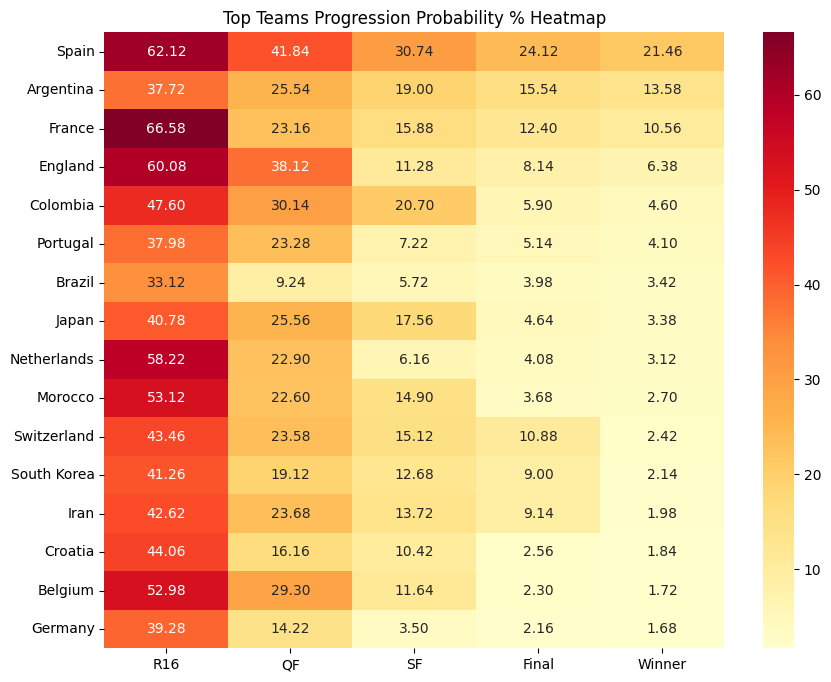

In [18]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    top_teams[['R16', "QF", "SF", "Final", "Winner"]],
    annot=True,
    fmt=".2f",
    cmap="YlOrRd"
)

plt.title("Top Teams Progression Probability % Heatmap")
plt.show()

In [19]:
!pip install xgboost

### XGBoost Model


In [20]:
import xgboost as xgb
# Load Model 

xgb_model = xgb.XGBClassifier()  # or XGBRegressor (must match original type)
xgb_model.load_model("xgb_model.json")

In [21]:
### XGBoost Model
ROUND_OF_32 = [
    (("A", 1), ("B", 2)),
    (("C", 1), ("D", 2)),
    (("E", 1), ("F", 2)),
    (("G", 1), ("H", 2)),
    (("I", 1), ("J", 2)),
    (("K", 1), ("L", 2)),

    (("B", 1), ("A", 2)),
    (("D", 1), ("C", 2)),
    (("F", 1), ("E", 2)),
    (("H", 1), ("G", 2)),
    (("J", 1), ("I", 2)),
    (("L", 1), ("K", 2)),
]

def predict_match_xgb(team1, team2, elo_dict, model):

    elo_home = elo_dict.get(team1, 1500)
    elo_away = elo_dict.get(team2, 1500)

    # Use Poisson model to get lambda
    lam_home, lam_away = get_lambda(
        team1, team2,
        elo_dict,
        beta_home,
        beta_away
    )

    data = pd.DataFrame([{
        "elo_home": elo_home,
        "elo_away": elo_away,
        "elo_diff": elo_home - elo_away,
        "lambda_home": lam_home,
        "lambda_away": lam_away
    }])

    probs = model.predict_proba(data)[0]

    return probs  # [away, draw, home]

def simulate_match_xgb(team1, team2, elo_dict, model):

    probs = predict_match_xgb(team1, team2, elo_dict, model)

    outcome = np.random.choice(
        ["away", "draw", "home"],
        p=probs
    )

    if outcome == "home":
        return team1
    elif outcome == "away":
        return team2
    else:
        return np.random.choice([team1, team2])


def simulate_group(group_teams, elo_dict, beta_home, beta_away):

    table = {
        team: {"points": 0, "gd": 0, "goals": 0}
        for team in group_teams
    }

    for team_a, team_b in combinations(group_teams, 2):

        lam_a, lam_b = get_lambda(
            team_a, team_b,
            elo_dict,
            beta_home,
            beta_away
        )

        goals_a = np.random.poisson(lam_a)
        goals_b = np.random.poisson(lam_b)

        table[team_a]["goals"] += goals_a
        table[team_b]["goals"] += goals_b

        table[team_a]["gd"] += goals_a - goals_b
        table[team_b]["gd"] += goals_b - goals_a

        if goals_a > goals_b:
            table[team_a]["points"] += 3
        elif goals_b > goals_a:
            table[team_b]["points"] += 3
        else:
            table[team_a]["points"] += 1
            table[team_b]["points"] += 1

    return sorted(
        table.items(),
        key=lambda x: (x[1]["points"], x[1]["gd"], x[1]["goals"]),
        reverse=True
    )


# SIMULATE ALL GROUPS
def simulate_group_stage(groups, elo_dict, beta_home, beta_away):

    group_results = {}
    third_place = []

    for group_name, teams in groups.items():

        standings = simulate_group(
            teams, elo_dict, beta_home, beta_away
        )

        group_results[group_name] = standings

        # store 3rd place
        third_place.append((group_name, standings[2]))

    return group_results, third_place

def get_best_third_places(third_place):

    ranked = sorted(
        third_place,
        key=lambda x: (
            x[1][1]["points"],
            x[1][1]["gd"],
            x[1][1]["goals"]
        ),
        reverse=True
    )

    return ranked[:8]

def get_knockout_teams(group_results, best_thirds):

    teams = []

    # top 2 from each group
    for group, standings in group_results.items():
        teams.append(standings[0][0])
        teams.append(standings[1][0])

    # add best 3rd
    for group_name, (team, stats) in best_thirds:
        teams.append(team)

    assert len(teams) == 32

    return teams

def seed_knockout(teams, elo_dict):
    return sorted(teams, key=lambda t: elo_dict.get(t, 1500), reverse=True)


def create_bracket(teams):
    return [(teams[i], teams[-i-1]) for i in range(len(teams)//2)]

def simulate_knockout_round_xgb(teams, elo_dict, model):

    matches = [(teams[i], teams[i+1]) for i in range(0, len(teams), 2)]

    winners = []

    for t1, t2 in matches:
        winners.append(simulate_match_xgb(t1, t2, elo_dict, model  ))

    return winners

def simulate_tournament_xgb(groups, elo_dict, model):

    progression = {team: {"R32":1,"R16":0,"QF":0,"SF":0,"Final":0,"Winner":0}
                   for group in groups.values() for team in group}

    # --- GROUP STAGE ---
    group_results, third_place = simulate_group_stage(
        groups, elo_dict, beta_home, beta_away
    )

    # --- BEST 3rd ---
    best_thirds = get_best_third_places(third_place)

    # --- 32 TEAMS ---
    knockout_teams = get_knockout_teams(group_results, best_thirds)

    for t in knockout_teams:
        progression[t]["R32"] = 1

    # --- STRUCTURED BRACKET ---
    seeded = seed_knockout(knockout_teams, elo_dict)

    # --- KNOCKOUTS ---
    r32 = simulate_knockout_round_xgb(seeded, elo_dict, model)
    for team in r32:
        progression[team]["R16"] += 1

    r16 = simulate_knockout_round_xgb(r32, elo_dict, model)
    for team in r16:
        progression[team]["QF"] += 1

    qf = simulate_knockout_round_xgb(r16, elo_dict, model)
    for team in qf:
        progression[team]["SF"] += 1
    sf = simulate_knockout_round_xgb(qf, elo_dict, model)
    for team in sf:
        progression[team]["Final"] += 1
    final = simulate_knockout_round_xgb(sf, elo_dict, model)
    for team in final:
        progression[team]["Winner"] += 1

    # Return winner
    return final[0], progression

def run_simulations_xgb(n, groups, elo_dict, model):
    winners = []
    progression_totals = {}

    for team in [t for g in groups.values() for t in g]:
        progression_totals[team] = {
            "R32":0,"R16":0,"QF":0,"SF":0,"Final":0,"Winner":0
        }

    for _ in range(n):

        winner, progression = simulate_tournament_xgb(
            groups,
            elo_dict,
            model
        )

        winners.append(winner)

        for team in progression:
            for stage in progression[team]:
                progression_totals[team][stage] += progression[team][stage]

    return Counter(winners), progression_totals

In [22]:
# No. of simulations to run
n = 5000

results_xgb, progression_totals_xgb = run_simulations_xgb(
    n,
    world_cup_2026_groups,
    elo_dict,
    xgb_model
)

In [23]:
# Normalize Progression
df_prog_xgb = pd.DataFrame(progression_totals_xgb).T / n

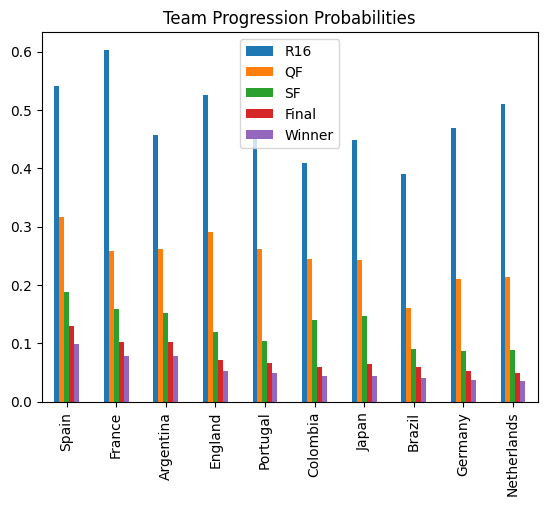

In [24]:
top_xgb = df_prog_xgb.sort_values("Winner", ascending=False).head(10)

top_xgb[["R16","QF","SF","Final","Winner"]].plot(kind="bar")
plt.title("Team Progression Probabilities")
plt.show()

In [25]:
df_results_xgb = pd.DataFrame.from_dict(results_xgb, orient="index", columns=["wins"])
df_results_xgb["probability"] = df_results_xgb["wins"] / df_results_xgb["wins"].sum()

df_results_xgb = df_results_xgb.sort_values("probability", ascending=False)

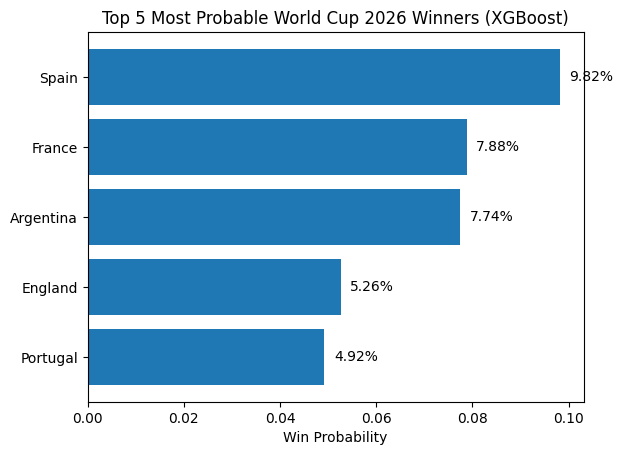

In [26]:

top_n_xgb = 5
top_teams_xgb = df_results_xgb.head(top_n_xgb)

plt.figure()

plt.barh(top_teams_xgb.index[::-1], top_teams_xgb["probability"][::-1])

for i, v in enumerate(top_teams_xgb["probability"][::-1]):
    plt.text(v + 0.002, i, f"{v:.2%}", va='center')

plt.xlabel("Win Probability")
plt.title("Top 5 Most Probable World Cup 2026 Winners (XGBoost)")

plt.show()

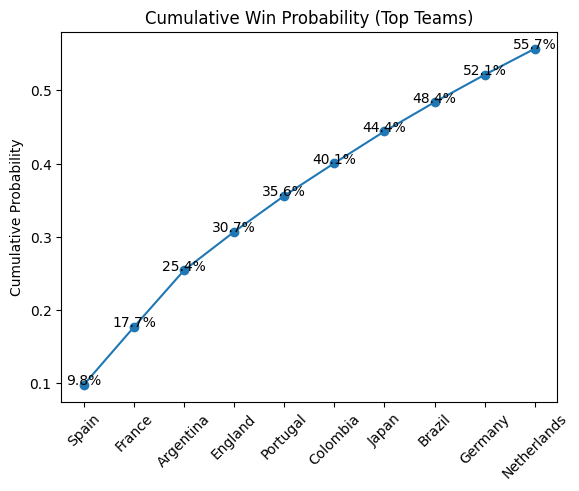

In [27]:
df_results_xgb["cumulative_prob"] = df_results_xgb["probability"].cumsum()

top_n_xgb = 10
top_xgb = df_results_xgb.head(top_n_xgb)

plt.figure()
plt.plot(top_xgb.index, top_xgb["cumulative_prob"], marker="o")

for i, v in enumerate(top_xgb["cumulative_prob"]):
    plt.text(i, v, f"{v:.1%}", ha='center')

plt.title("Cumulative Win Probability (Top Teams)")
plt.ylabel("Cumulative Probability")
plt.xticks(rotation=45)

plt.show()

In [28]:
top_teams.head(10)

,R32,R16,QF,SF,Final,Winner
Spain,100.0,62.12,41.84,30.74,24.12,21.46
Argentina,100.0,37.72,25.54,19.00,15.54,13.58
France,100.0,66.58,23.16,15.88,12.40,10.56
England,100.0,60.08,38.12,11.28,8.14,6.38
Colombia,100.0,47.60,30.14,20.70,5.90,4.60
Portugal,100.0,37.98,23.28,7.22,5.14,4.10
Brazil,100.0,33.12,9.24,5.72,3.98,3.42
Japan,100.0,40.78,25.56,17.56,4.64,3.38
Netherlands,100.0,58.22,22.90,6.16,4.08,3.12
Morocco,100.0,53.12,22.60,14.90,3.68,2.70


In [29]:
top_teams_xgb.head(10)

,wins,probability
Spain,491,0.0982
France,394,0.0788
Argentina,387,0.0774
England,263,0.0526
Portugal,246,0.0492
